<div style="background-color: #d9ffd4; padding: 20px; border-radius: 10px;">
    <h1 style="color: #2F4F4F; font-family: Calibri, sans-serif; text-align: center;">Jornada 1</h1>
    <p style="color: #2F4F4F; font-family: Calibri, Courier, monospace; text-align: center; font-size: 24px;">
        Repaso: Solución Numérica de Ecuaciones Diferenciales Ordinarias (EDO)
    </p>
</div>

### **Ecuaciones Diferenciales: Repaso y Preparación para Segundo Orden**

Una ecuación diferencial es una relación que involucra una función desconocida y sus derivadas. En este contexto, la incógnita no es un valor numérico sino una **función** $ y(t) $ que debe satisfacer una igualdad diferencial.

Consideremos el siguiente ejemplo:

$$
 y'(t) = y^2(t) e^t
$$

La incógnita es $ y(t) $, y la ecuación involucra su derivada primera. Resolverla implica determinar la familia de funciones que cumplen esta relación.

La solución general es:

$$
y(t) = \frac{1}{c - e^t}, \quad c = \text{constante arbitraria}.
$$

#### **Constante de integración y problemas de valor inicial**

La presencia de la constante $ c $ es consecuencia del proceso de integración durante la resolución. Como es sabido, la integración introduce una constante arbitraria porque existen infinitas funciones con la misma derivada. 

Para determinar una solución única, se requiere un **problema de valor inicial (PVI)**, en el que se especifica la condición de la función (y, si corresponde, de sus derivadas) en un punto dado.


En este caso, encontramos una solución analítica para esta ecuación, sin embargo, esto no siempre es posible debido a la complejidad de algunas ecuaciones diferenciales, por esta razón, es que diversos autores han desarrollado métodos numéricos para encontrar soluciones aproximadas a dichas ecuaciones.

Un primer algoritmo es el método de Euler.

<div style="background-color: #d4eeff; color: black; padding: 10px; border-radius: 5px;">

### **Método de Euler**

Considere una ecuación diferencial de primer orden en su forma estándar:

$$ \frac{dy}{dt} = f(t, y) $$

Para aproximar la solución, utilizamos el método *forward difference* para encontrar derivadas numéricas:

$$ \frac{dy}{dt} \approx  \frac{y_{n+1} - y_n}{h} $$

De esta forma, tenemos:

$$ \frac{y_{n+1} - y_n}{h} = f(t_n, y_n) $$

Despejando $ y_{n+1} $:


$$ \boxed{ y_{n+1} = y_n + h f(t_n, y_n) }$$

Además:

$$ \boxed{ t_{n+1} = t_n + h }$$

Este método nos permite calcular iterativamente la solución de una ecuación diferencial a partir de su condición inicial.

</div>

**Interpretación Gráfica:**

<p align="center">
  <img src="solucion_analitca_vs_solucion_numerica.png" width="40%">
</p>

<div style="background-color: #FFF9AD; color: black; padding: 10px; border-radius: 5px;">

**Ejercicio:** Resolvamos el problema anterior ($y'(t) = y^2(t) e^t$) usando Euler y comparemos con la solución analítica, para $t \in [0, 1]$. Use $h=0.1$ y la condición inicial $y(0) = 0.5$
</div>

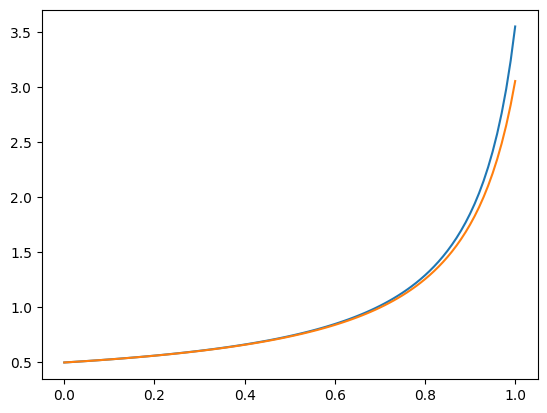

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def f(t, y):
    return y**2 * np.exp(t)

def euler_method(f, t0, y0, h, tf):
    t = np.arange(t0,tf + h,h) # crea un vector con los parametros dados
    y = np.ones_like(t) #basado en el largo de t quiero un vector de 0's
    y[0] = y0
    for n in range(len(t)-1):
         y[n+1] = y[n] + h * f(t[n], y[n]) # con [] accedes a un vector  
    return t, y

def y_exacta(t):
    return 1 / (3 - np.exp(t))

h = 0.01
t = np.linspace(start=0,stop=1,num=200)
t, y = euler_method(f=f, t0=0, y0=1/2, h=h, tf=1)
plt.plot(t,y_exacta(t))
plt.plot(t, y)


El siguiente código ilustra el proceso iterativo que sigue el método de Euler para encontrar la solución:

In [12]:
for i in range(9):
    print(f"y{i+1} = y{i} + h * f(t{i}, y{i}) = {str(round(y[i], 2)).ljust(4, '0')} + {h} * f({str(round(t[i], 2)).ljust(4, '0')}, {str(round(y[i], 2)).ljust(4, '0')}) = {str(round(y[i+1], 2)).ljust(4, '0')}")

y1 = y0 + h * f(t0, y0) = 1.00 + 0.01 * f(0.00, 1.00) = 1.01
y2 = y1 + h * f(t1, y1) = 1.01 + 0.01 * f(0.01, 1.01) = 1.02
y3 = y2 + h * f(t2, y2) = 1.02 + 0.01 * f(0.02, 1.02) = 1.03
y4 = y3 + h * f(t3, y3) = 1.03 + 0.01 * f(0.03, 1.03) = 1.04
y5 = y4 + h * f(t4, y4) = 1.04 + 0.01 * f(0.04, 1.04) = 1.05
y6 = y5 + h * f(t5, y5) = 1.05 + 0.01 * f(0.05, 1.05) = 1.06
y7 = y6 + h * f(t6, y6) = 1.06 + 0.01 * f(0.06, 1.06) = 1.08
y8 = y7 + h * f(t7, y7) = 1.08 + 0.01 * f(0.07, 1.08) = 1.09
y9 = y8 + h * f(t8, y8) = 1.09 + 0.01 * f(0.08, 1.09) = 1.10


### **Ejercicio: Caída libre con resistencia del aire**

Queremos resolver la ecuación diferencial que describe la caída libre de una partícula de masa $m$, considerando la fuerza de resistencia del aire:

$$ F_r = -k v $$

Partimos con la segunda ley de Newton:

$$ \sum F = ma \quad \Rightarrow \quad F_g + F_r = m \frac{dv}{dt} $$

Entonces:

$$ \pm mg - kv = m \frac{dv}{dt} $$

Nuestro objetivo es encontrar la velocidad en función del tiempo, $v(t)$.

- Si tomamos hacia abajo como positivo, usamos $+mg$.
- Si tomamos hacia arriba como positivo, usamos $-mg$.
- La fuerza de resistencia del aire siempre es negativa porque actúa en sentido opuesto al movimiento.


<p align="center">
  <img src="caida_libre.png" style="max-width: 25%; height: auto;">
</p>

En el sistema de referencia del esquema (eje $y$ positivo hacia arriba), la ecuación queda:

$$ -mg - kv = m \frac{dv}{dt} $$

Forma estándar:

$$ \frac{dv}{dt} = -g - \frac{k}{m}v $$

Con condición inicial:

$$ v(0) = 0 $$

La solución analítica es:

$$ v(t) = \frac{mg}{k} \big( e^{-kt/m} - 1 \big) $$

---

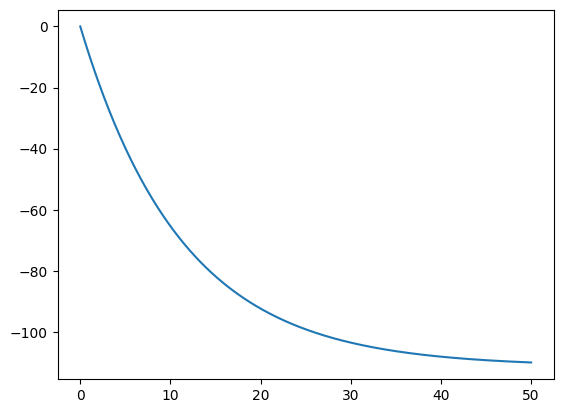

In [26]:
### Resuelva este problema nuevamente con Euler
def euler_method(f, t0, v0, h, tf):
    t = np.arange(t0,tf + h,h) # crea un vector con los parametros dados
    v = np.ones_like(t) #basado en el largo de t quiero un vector de 0's
    v[0] = v0
    for n in range(len(t)-1):
         v[n+1] = v[n] + h * f(t[n], v[n]) # con [] accedes a un vector  
    return t, v

def f(t,v):
     g = 9.81
     k = 6
     m= 68.1
     return -g - (k*v)/m

t0 = 0
v0 = 0
h = 0.1
tf = 50
t,v = euler_method(f=f ,t0=t0, v0=v0, h=h, tf=tf)
plt.plot(t,v)


### **Ejercicio: Caída libre con resistencia del aire (formulación para segundo orden)**

Consideremos nuevamente el problema de la caída libre de una partícula de masa $m$, pero ahora lo plantearemos en el contexto de una **ecuación diferencial de segundo orden**, ya que queremos describir tanto la velocidad $v(t)$ como la posición $y(t)$.

La segunda ley de Newton indica:

$$ m \frac{dv}{dt} = -mg - k v $$

Dividimos por la masa para expresar la aceleración:

$$ \frac{dv}{dt} = -g - \frac{k}{m} v $$

Esta ecuación describe la evolución de la **velocidad**, pero para obtener también la **posición**, debemos recordar la relación cinemática:

$$ \frac{dy}{dt} = v $$

Podemos entonces expresar el sistema como un conjunto de ecuaciones de primer orden:

- Para la velocidad:  
  $$ \frac{dv}{dt} = f(t, y, v) ~~\text{ donde, en este caso: }~~ f(t, y, v) = -g - \frac{k}{m} v $$

- Para la posición:  
  $$ \frac{dy}{dt} = v $$

De esta forma, el problema original de segundo orden (en $y$) se transforma en un sistema de **dos ecuaciones de primer orden**, lo que facilita su resolución numérica.


<div style="background-color: #d4eeff; color: black; padding: 10px; border-radius: 5px;">

### **Método de Euler para ecuaciones de segundo orden**

Consideremos un sistema de ecuaciones diferenciales de primer orden equivalente a una ecuación de segundo orden:

$$
\begin{cases}
\frac{dy}{dt} = v \\
\frac{dv}{dt} = f(t, y, v)
\end{cases}
$$

Para aproximar la solución, aplicamos el método *forward difference* a cada variable:

$$
\frac{y_{n+1} - y_n}{h} \approx v_n
$$

$$
\frac{v_{n+1} - v_n}{h} \approx f(t_n, y_n, v_n)
$$

Despejando las actualizaciones:

$$ \boxed{y_{n+1} = y_n + h \, v_n} $$

$$ \boxed{v_{n+1} = v_n + h \, f(t_n, y_n, v_n)} $$

Además:

$$ \boxed{t_{n+1} = t_n + h} $$

De esta forma, podemos calcular iterativamente la posición $y$ y la velocidad $v$ de un objeto bajo fuerzas conocidas, a partir de las condiciones iniciales $y_0$ y $v_0$.

</div>


<div style="background-color: #FFF9AD; color: black; padding: 10px; border-radius: 5px;">

**Ejercicio:** Resolvamos la caída libre con resistencia del aire utilizando el **método de Euler para segundo orden**. Considere el sistema:

$$
\begin{cases}
\frac{dy}{dt} = v \\
\frac{dv}{dt} = -g - \frac{k}{m} v
\end{cases}
$$

para $t \in [0, 5]$ s, con paso $h = 0.1$ s y condiciones iniciales:

$$ y(0) = 0, \quad v(0) = 0 $$

Implemente el método de Euler para aproximar iterativamente $y(t)$ y $v(t)$, y compare los resultados con la solución analítica:

$$ v(t) = \frac{mg}{k} \big( e^{-kt/m} - 1 \big), \quad y(t) = \frac{m g}{k} \left( t + \frac{m}{k} ( e^{-kt/m} - 1 ) \right) $$

</div>


In [14]:
### Implemente el método de Euler segundo orden y resolva el problema anterior

def euler_method_second_order():

    return ??

SyntaxError: invalid syntax (2022861028.py, line 5)

### **Uso de `fig` y `ax` en Matplotlib**

Cuando usamos `fig, ax = plt.subplots()`, estamos creando una figura y uno o más ejes (subplots) para graficar. A continuación, detallamos el rol de cada una de las variables:

- **`fig` (Figura):** Esta variable hace referencia a la figura completa, que es el contenedor global de todo el gráfico. A través de `fig`, podemos modificar propiedades de la figura, como el tamaño, el título global, y otras configuraciones que afectan a todo el conjunto de gráficos.

- **`ax` (Ejes):** La variable `ax` es un array o una lista (dependiendo del número de subplots) donde cada elemento es un objeto `AxesSubplot`. Cada objeto `AxesSubplot` representa un gráfico individual dentro de la figura. A través de `ax`, podemos personalizar cada gráfico de manera independiente, como ajustar los títulos, etiquetas de los ejes, leyendas, entre otros elementos.

En resumen, `fig` nos permite controlar aspectos generales de la figura completa, mientras que `ax` nos da control sobre cada gráfico específico dentro de la figura.

<div style="background-color: #FFF9AD; color: black; padding: 10px; border-radius: 5px;">

**Ejercicio:** Utilice `fig, ax = plt.subplots()` para expresar las gráficas de los resultados de la caída libre.
</div>


In [ ]:
### Uso de `fig` y `ax` en Matplotlib



El método de Euler es una técnica sencilla y directa para aproximar soluciones de ecuaciones diferenciales. Sin embargo, su precisión es limitada, especialmente cuando el paso $h$ es relativamente grande o cuando la dinámica del sistema es compleja. 

Para obtener resultados más precisos y estables, se recomienda el uso de métodos numéricos más avanzados, como los **métodos de Runge-Kutta**, que permiten aproximar soluciones con mayor exactitud y confiabilidad.


<div style="background-color: #d9ffd4; color: black; padding: 10px; border-radius: 5px;">

**Conclusión: ¿Qué aprendimos?**

- Revisamos el concepto de ecuaciones diferenciales de primer y segundo orden, y cómo transformarlas en sistemas de ecuaciones de primer orden.
- Aplicamos el **método de Euler** para aproximar soluciones numéricas de sistemas de segundo orden, como el caso de la caída libre con resistencia del aire.
- Comparamos soluciones numéricas con soluciones analíticas para evaluar precisión y comportamiento del método.
- Analizamos la utilidad y limitaciones del método de Euler, reconociendo la necesidad de métodos más avanzados como **Runge-Kutta** para obtener mayor exactitud en problemas más complejos.
- Aprendimos a utilizar `fig` y `ax` en `matplotlib` para crear y personalizar gráficos individuales y múltiples subplots dentro de una misma figura, controlando tanto los elementos globales como los específicos de cada gráfico.

**Próxima Jornada:** Método de Euler segundo orden para problemas en 2D

</div>


<div style="padding: 15px; border-top: 2px solid #2F4F4F; margin-top: 30px; background-color: var(--custom-bg-color); color: var(--custom-text-color);">
    <p style="font-family: Calibri, sans-serif; text-align: left; font-size: 16px;">
        Omar Fernández <br>
        Profesor de Física Computacional IV para Astrofísica <br>
        Ingeniero Físico <br>
        <a href="mailto:omar.fernandez.o@usach.cl" class="email-link">omar.fernandez.o@usach.cl</a> <br>
    </p>
</div>

<style>
:root {
    --custom-bg-color: #F8F8F8;
    --custom-text-color: #2F4F4F;
    --custom-link-color: blue;
}

@media (prefers-color-scheme: dark) {
    :root {
        --custom-bg-color: #444444;
        --custom-text-color: #F8F8F8;
        --custom-link-color: magenta;
    }
}

.email-link {
    color: var(--custom-link-color);
}
</style>